In [66]:
import importlib
import auxfun
importlib.reload(auxfun)
from auxfun import *

In [67]:
path = "..\\Envíos\\historico_operativa.xlsx"
fecha_fin = "2026-05-07"
historico_valor_cartera(path, fecha_fin, capital_inicial=10_000_000, hoja="Operativa", incluir_costes=True)

,Cash,Valor acciones,Dividendos diarios,Valor cartera,Rentabilidad diaria
Date,,,,,
2026-03-12,0.000000,9.990013e+06,0.000,9.990013e+06,0.000000
2026-03-13,0.000000,9.908388e+06,0.000,9.908388e+06,-0.008171
2026-03-16,0.000000,9.973624e+06,0.000,9.973624e+06,0.006584
2026-03-17,0.000000,1.000886e+07,0.000,1.000886e+07,0.003533
2026-03-18,0.000000,9.867523e+06,0.000,9.867523e+06,-0.014121
2026-03-19,0.000000,9.586114e+06,0.000,9.586114e+06,-0.028519
2026-03-20,-2665.153383,9.447849e+06,0.000,9.445184e+06,-0.014701
2026-03-23,4263.846617,9.521885e+06,6929.000,9.526149e+06,0.008572
2026-03-24,4263.846617,9.492344e+06,0.000,9.496608e+06,-0.003101


In [68]:
universo_tickers = get_eurostoxx50_tickers()
semanal = auxfun.tabla_semanal_atribucion(
    archivo=path,
    universo_tickers=universo_tickers,
    fecha_fin=fecha_fin,
    capital_inicial=10_000_000
)

detalle_acumulado, final = auxfun.encadenar_atribucion(semanal)
semanal_fmt, final_fmt = auxfun.formatear_atribucion(semanal, final)

In [69]:

display(semanal_fmt)
display(final_fmt)

,NAV inicial,NAV final,Rent. cartera neta,Alpha,Ef. selección,Ef. pesos,Costes
Periodo,,,,,,,
2026-03-12 → 2026-03-20,"10,000.0 k€","9,447.2 k€",-5.53%,-0.91%,-0.32%,-0.49%,-0.10%
2026-03-20 → 2026-03-27,"9,447.2 k€","9,410.7 k€",-0.39%,-0.54%,-0.11%,-0.41%,-0.02%
2026-03-27 → 2026-04-07,"9,410.7 k€","9,723.8 k€",3.33%,0.43%,0.07%,0.42%,-0.06%
2026-04-07 → 2026-04-10,"9,723.8 k€","10,137.2 k€",4.25%,-0.66%,0.65%,-1.29%,-0.02%
2026-04-10 → 2026-04-17,"10,137.2 k€","10,159.0 k€",0.21%,-2.09%,-0.35%,-1.72%,-0.02%
2026-04-17 → 2026-04-24,"10,159.0 k€","10,116.9 k€",-0.41%,2.14%,0.31%,1.86%,-0.03%
2026-04-24 → 2026-05-04,"10,116.9 k€","10,159.8 k€",0.42%,1.34%,0.38%,0.99%,-0.04%
2026-05-04 → 2026-05-08,"10,159.8 k€","10,181.5 k€",0.21%,-2.18%,0.07%,-2.22%,-0.03%
2026-05-08 → 2026-05-11,"10,181.5 k€","10,179.6 k€",-0.02%,-0.16%,-0.05%,-0.09%,-0.02%


,Cartera,BMK
NAV final,"10,179.6 k€","10,444.7 k€"
Resultado,179.6 k€ (1.80%),444.7 k€ (4.45%)
Rentabilidad,1.80%,4.45%
Volatilidad anualizada,19.72%,21.30%
Sharpe,0.61,1.28
Alpha vs BMK,-265.2 k€ (-2.65%),
Ef. selección,65.1 k€ (0.65%),
Ef. pesos,-295.0 k€ (-2.95%),
Costes,-35.3 k€ (-0.35%),


c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:690: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


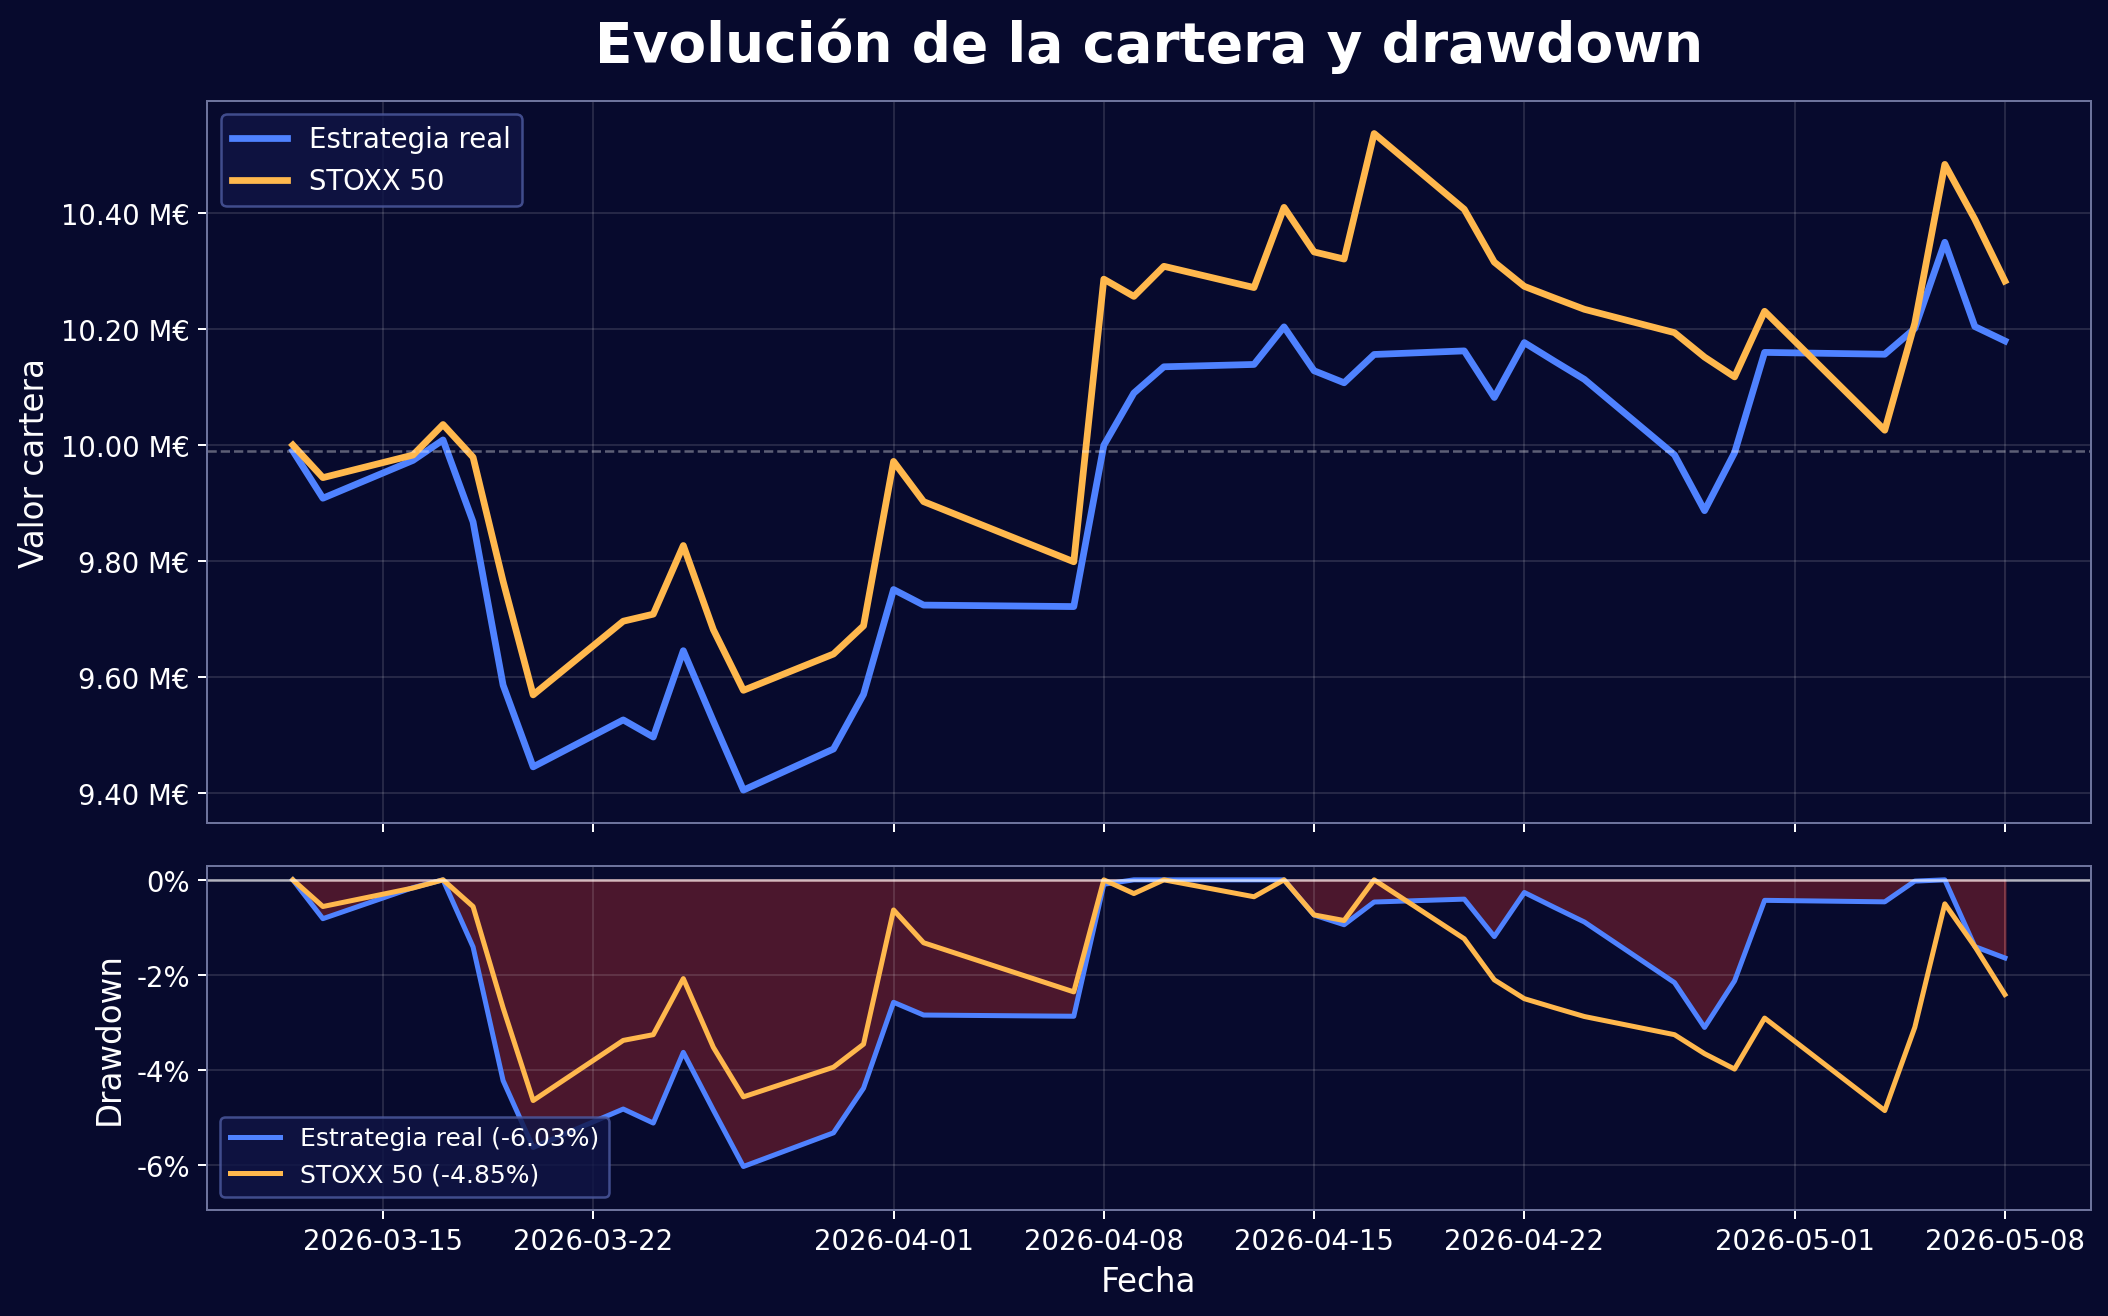

In [70]:
series_grafico, semanal, final, tabla_metricas, tabla_metricas_fmt = series_diarias_cartera_bmks(
    archivo=path,
    universo_tickers=universo_tickers,
    fecha_fin=fecha_fin,
    capital_inicial=10_000_000,
    benchmark="^STOXX50E"
)

fig, axes = auxfun.grafico_evolucion_drawdown(
    series_grafico,
    titulo="Evolución de la cartera y drawdown"
)

P&L medio por activo: 6,906.34 €


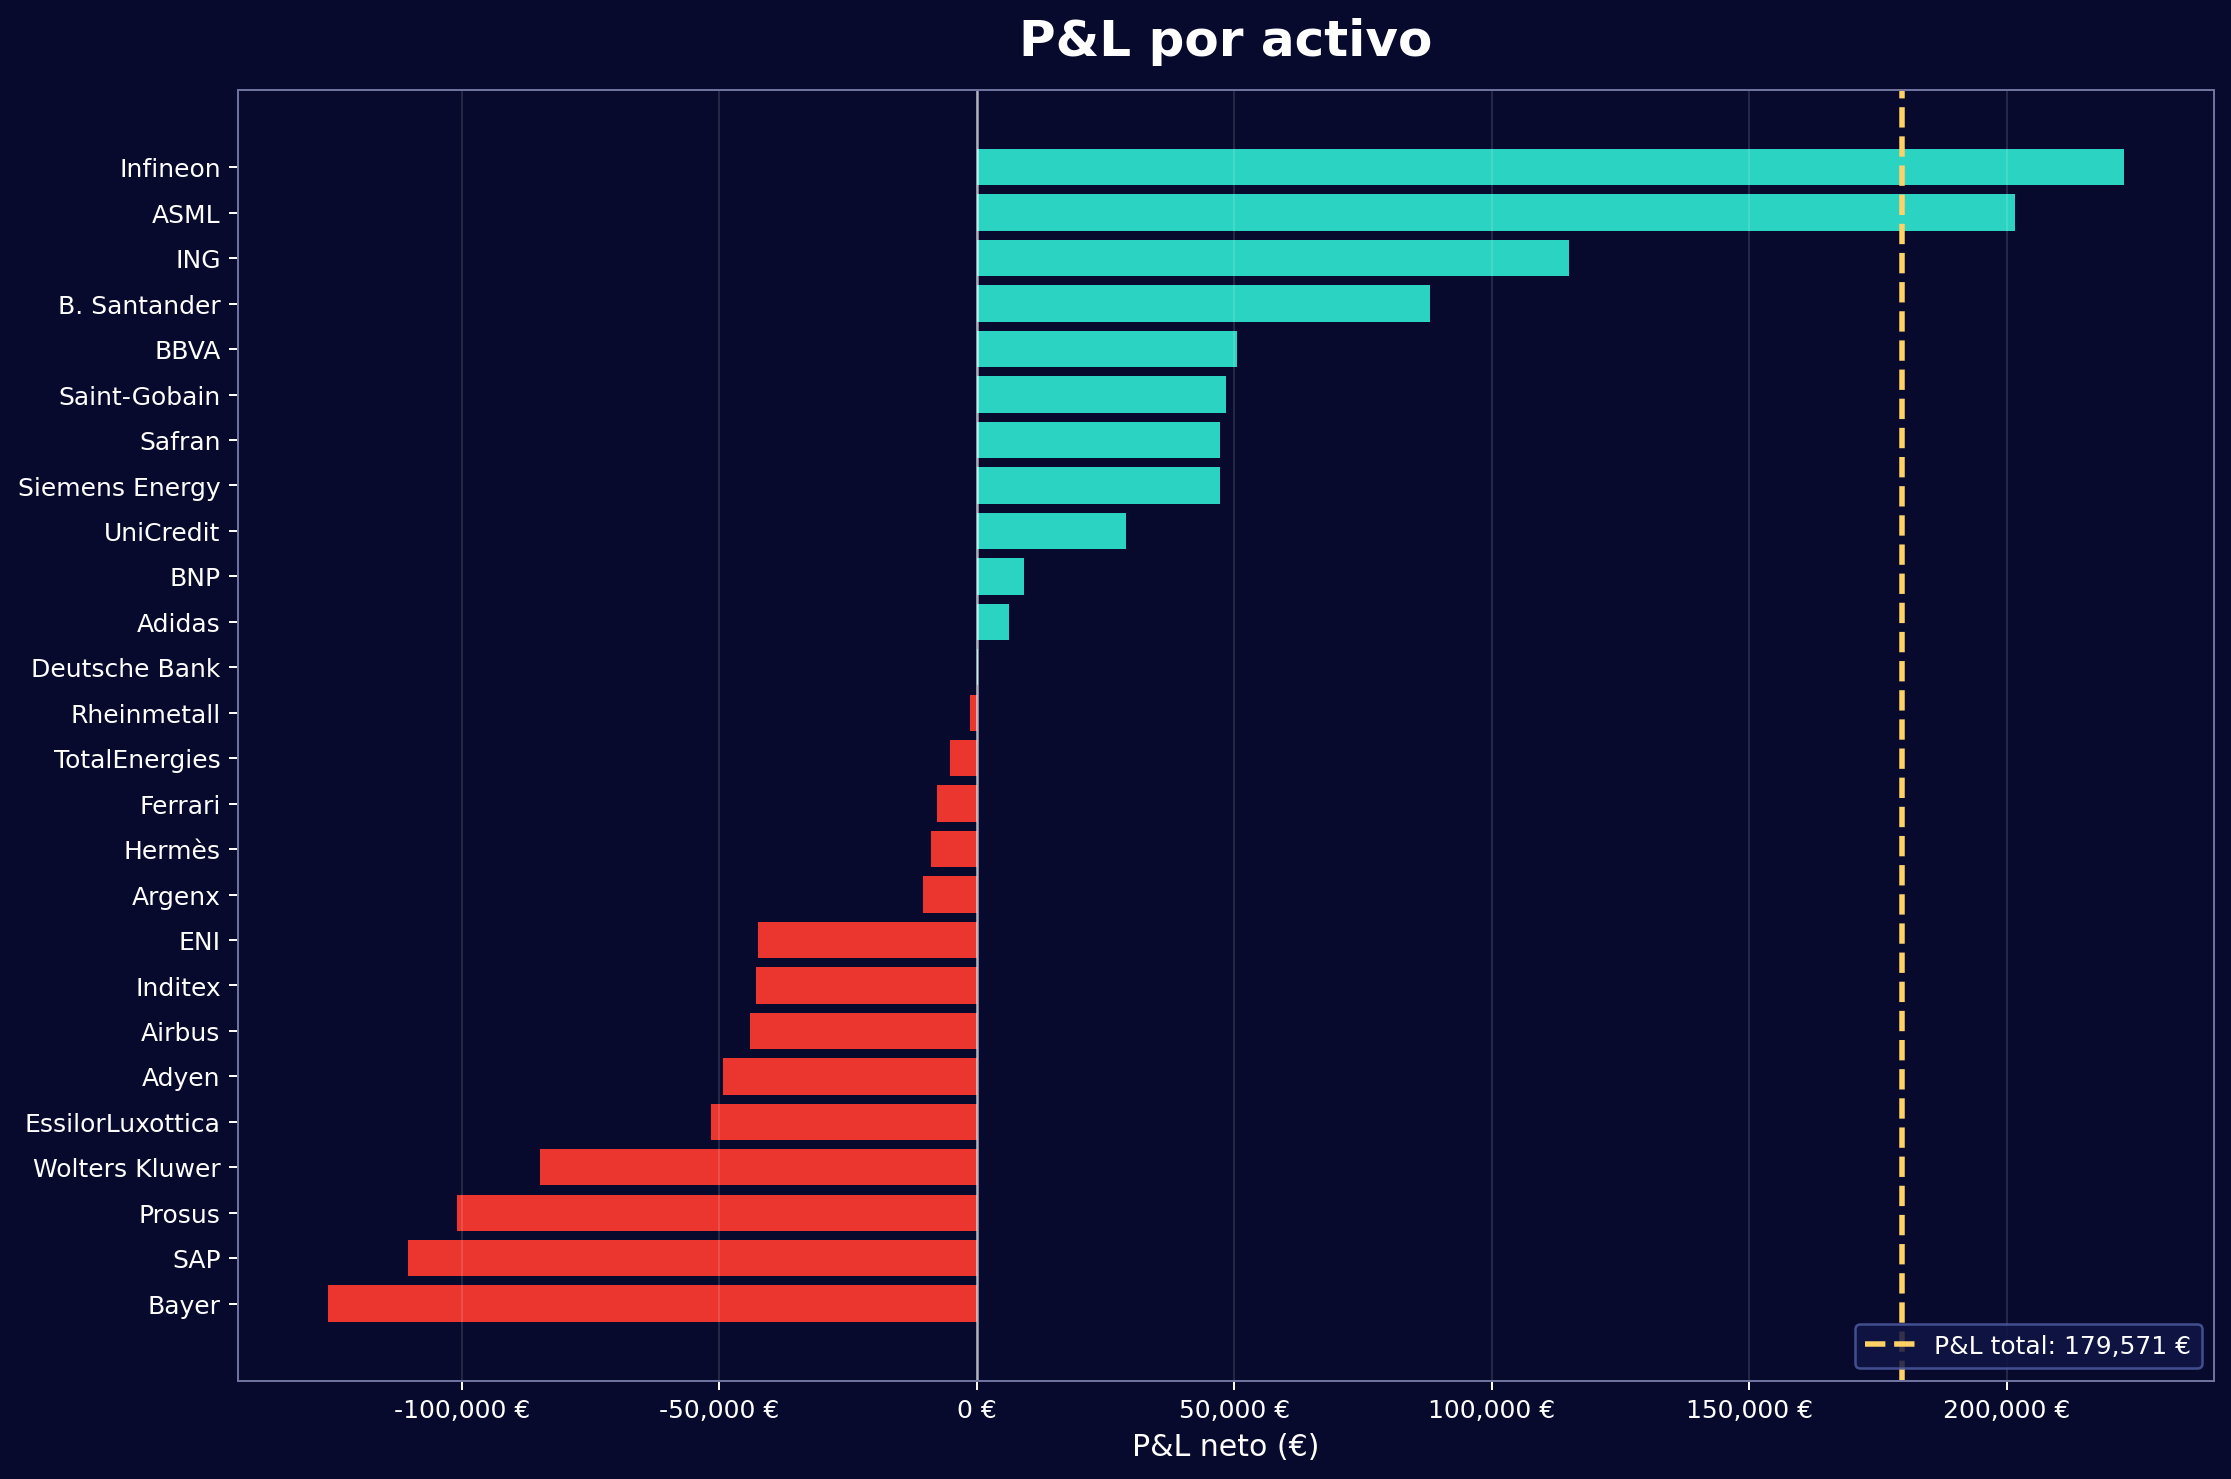

,P&L (€)
Activo,
Bayer,"-125,996 €"
SAP,"-110,385 €"
Prosus,"-100,944 €"
Wolters Kluwer,"-84,744 €"
EssilorLuxottica,"-51,528 €"
Adyen,"-49,366 €"
Airbus,"-44,023 €"
Inditex,"-42,802 €"
ENI,"-42,497 €"


In [71]:
pnl_activos, fig, ax = auxfun.pnl_por_activo(
    archivo=path,
    fecha_fin=fecha_fin,
    capital_inicial=10_000_000
)

display(pnl_activos.style.format({"P&L (€)": "{:,.0f} €"}))